# Esercizio 10 — Traveling Salesman Problem con algoritmo genetico parallelo

In questo esercizio ho parallelizzato l'algoritmo genetico sviluppato per il Traveling Salesman Problem usando MPI. L'idea è quella del modello a **continenti**: ogni processo MPI evolve una propria popolazione, quindi una propria ricerca genetica, e periodicamente i continenti si scambiano il miglior individuo trovato.

Il problema consiste nel trovare il cammino chiuso di lunghezza minima che visita ogni città una sola volta. La funzione costo usata è

$$
L^{(1)} = \sum_{i=1}^{N} |\vec{x}_{i+1}-\vec{x}_i| ,
\qquad \vec{x}_{N+1}=\vec{x}_1 .
$$

In questa analisi considero due casi:

- città generate casualmente all'interno di un quadrato;
- i 110 capoluoghi di provincia italiani.

Per ogni caso confronto due strategie a parità di parametri genetici e numero di processi:

- **independent**: ogni processo esegue un GA indipendente;
- **migration**: ogni processo esegue un GA indipendente, ma ogni $N_\mathrm{migr}$ generazioni scambia il proprio miglior individuo con un altro continente.

## Struttura dell'algoritmo parallelo

Il programma è scritto secondo il paradigma **SPMD** (*Single Program Multiple Data*): tutti i processi eseguono lo stesso codice, ma si distinguono tramite il proprio `rank`.

Nel `main.cpp` ogni processo inizializza MPI e legge il proprio identificativo:

```cpp
MPI_Init(&argc, &argv);

int rank, size;
MPI_Comm_rank(MPI_COMM_WORLD, &rank);
MPI_Comm_size(MPI_COMM_WORLD, &size);
```

Il valore `size` è il numero totale di processi usati, mentre `rank` identifica il singolo processo. In questo modo ogni rank può evolvere una popolazione diversa, ma usando lo stesso eseguibile.

Per evitare che tutti i processi esplorino la stessa sequenza casuale, il generatore viene inizializzato usando righe diverse del file `Primes`:

```cpp
Random rnd = InitializeRandom(rank);
```

La keyword `PROBLEM_NAME` nel file `input.dat` permette di usare lo stesso codice sia per il quadrato sia per l'Italia. A partire da `problem_name` e da `run_type`, il codice costruisce automaticamente i nomi dei file di output:

```cpp
string run_type = "independent";

if(migration == 1) {
    run_type = "migration";
}

string output_folder = "../OUTPUT/" + problem_name;

string best_coord_file_rank =
    output_folder + "/bestpath_coordinates_" + problem_name + "_" +
    run_type + "_rank_" + to_string(rank) + ".dat";

string history_file_rank =
    output_folder + "/history_" + problem_name + "_" +
    run_type + "_rank_" + to_string(rank) + ".dat";

string summary_file_run =
    output_folder + "/final_summary_" + problem_name + "_" +
    run_type + ".dat";
```

Questa scelta evita di scrivere nell'input molti prefissi diversi per file che differiscono solo per `square/italy` e `independent/migration`.

## Logica della migrazione MPI

Nella versione con migrazione, ogni $N_\mathrm{migr}$ generazioni i processi si scambiano il miglior cammino trovato. La migrazione non coinvolge tutta la popolazione, ma solo un individuo per continente: questo mantiene basso il costo di comunicazione.

La funzione `MigrateBestIndividuals` procede in questo modo:

1. ogni rank ordina la propria popolazione;
2. il rank 0 genera una permutazione casuale dei rank;
3. la permutazione viene comunicata a tutti con `MPI_Bcast`;
4. ogni processo invia il proprio miglior cammino al rank successivo nella permutazione;
5. ogni processo riceve un cammino dal rank precedente;
6. il cammino ricevuto viene inserito nella popolazione al posto del peggiore individuo.

La parte centrale è:

```cpp
MPI_Bcast(permutation.data(), size, MPI_INT, 0, MPI_COMM_WORLD);

int dest = permutation[(my_position + 1) % size];
int source = permutation[(my_position - 1 + size) % size];

vector<int> send_path = pop.GetBestPath();
vector<int> recv_path(send_path.size());

MPI_Isend(send_path.data(), n_cities, MPI_INT,
          dest, tag, MPI_COMM_WORLD, &req);

MPI_Recv(recv_path.data(), n_cities, MPI_INT,
         source, tag, MPI_COMM_WORLD, &stat_recv);

MPI_Wait(&req, &stat_send);

pop.ReplaceWorstPath(recv_path, map);
```

`MPI_Bcast` è necessario perché tutti i processi devono usare la stessa permutazione dei rank. Se ogni processo scegliesse da solo con chi comunicare, gli invii e le ricezioni non sarebbero coerenti.

Per lo scambio uso `MPI_Isend`, cioè un invio non bloccante, seguito da una `MPI_Recv` bloccante e poi da `MPI_Wait`. Questa scelta evita situazioni di deadlock: tutti i processi possono iniziare l'invio e poi mettersi in ricezione.

Il cammino ricevuto viene inserito con `ReplaceWorstPath`, non sostituendo il migliore locale. In questo modo un migrante peggiore non cancella il miglior risultato già trovato dal continente.

## File riassuntivo finale

La storia temporale viene salvata solo per il `rank 0`, perché serve a visualizzare l'andamento del GA durante le generazioni.

Per conoscere invece il risultato finale di tutti i continenti, alla fine della simulazione ogni rank raccoglie due dati:

```cpp
double local_summary[2];

local_summary[0] = pop.GetBestLength();
local_summary[1] = pop.GetMeanBestHalf();
```

Poi tutti i rank inviano questi due valori al `rank 0` tramite `MPI_Gather`:

```cpp
vector<double> global_summary(2 * size);

MPI_Gather(local_summary, 2, MPI_DOUBLE,
           global_summary.data(), 2, MPI_DOUBLE,
           0, MPI_COMM_WORLD);
```

Il rank 0 scrive quindi un file del tipo

```text
# rank best_length mean_best_half
0 ...
1 ...
2 ...
...
```

Questa scelta è importante perché il notebook non deve ricalcolare la lunghezza dei percorsi a partire dalle coordinate. La funzione costo viene calcolata dal C++, mentre Python viene usato solo per leggere i dati e produrre i grafici.

## Parametri delle simulazioni

Per entrambi i problemi ho usato una popolazione di 1000 individui e 1000 generazioni. Nella versione con migrazione lo scambio tra continenti avviene ogni 50 generazioni.

| Caso | $N_\mathrm{cities}$ | $N_\mathrm{pop}$ | $N_\mathrm{gen}$ | $p_c$ | $p_\mathrm{swap}$ | $p_\mathrm{inv}$ | $p_\mathrm{shift}$ | $p_\mathrm{block}$ |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Quadrato | 34 | 1000 | 1000 | 0.80 | 0.10 | 0.10 | 0.10 | 0.10 |
| Italia | 110 | 1000 | 1000 | 0.80 | 0.08 | 0.15 | 0.12 | 0.10 |

Per ogni caso ho eseguito il codice due volte, cambiando solo il parametro

```text
MIGRATION        0
```

oppure

```text
MIGRATION        1
```

Nel caso con migrazione ho usato

```text
N_MIGR           50
```

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

OUTPUT_DIR = Path("OUTPUT")
plt.rcParams.update({"font.size": 12})

# 1. Città nel quadrato

Il quadrato è un primo test geometrico del codice. Non rappresenta il caso finale dell'esercizio, ma è utile per controllare che gli operatori genetici, i vincoli sulla permutazione e la migrazione MPI funzionino correttamente.

Nel confronto seguente uso:

- `history_square_independent_rank_0.dat` e `history_square_migration_rank_0.dat` per l'andamento di best path e best half del rank 0;
- `final_summary_square_independent.dat` e `final_summary_square_migration.dat` per identificare il miglior rank finale tra tutti i continenti.

In [2]:
# File riassuntivi finali: ogni riga contiene
# rank, miglior lunghezza finale e media della metà migliore.
summary_square_independent = np.loadtxt(
    OUTPUT_DIR / "square" / "final_summary_square_independent.dat",
    comments="#"
)

summary_square_migration = np.loadtxt(
    OUTPUT_DIR / "square" / "final_summary_square_migration.dat",
    comments="#"
)

# History del rank 0: generazione, miglior cammino, media metà migliore.
history_square_independent = np.loadtxt(
    OUTPUT_DIR / "square" / "history_square_independent_rank_0.dat",
    comments="#"
)

history_square_migration = np.loadtxt(
    OUTPUT_DIR / "square" / "history_square_migration_rank_0.dat",
    comments="#"
)

# Scelgo il rank finale migliore cercando il minimo nella colonna L_best.
best_square_independent = summary_square_independent[np.argmin(summary_square_independent[:, 1])]
best_square_migration = summary_square_migration[np.argmin(summary_square_migration[:, 1])]

# Il rank deve essere convertito a intero, perché entra nel nome dei file.
best_rank_square_independent = int(best_square_independent[0])
best_rank_square_migration = int(best_square_migration[0])

print("Run           L_best        Best half")
print("Independent  %.4f      %.4f" % (best_square_independent[1], best_square_independent[2]))
print("Migration    %.4f      %.4f" % (best_square_migration[1], best_square_migration[2]))

Run           L_best        Best half
Independent  4.7684      4.9712
Migration    4.7684      5.0863


## 1.1 Andamento del costo — run indipendente

Nel grafico mostro il miglior cammino e la media della metà migliore della popolazione per il `rank 0`. La media sulla metà migliore dà un'indicazione della qualità complessiva della popolazione.

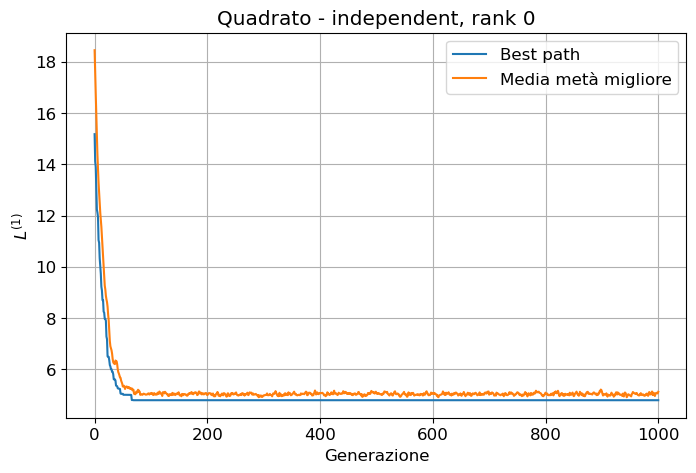

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

# Miglior cammino trovato dal rank 0 a ogni generazione.
ax.plot(history_square_independent[:, 0],
        history_square_independent[:, 1],
        label="Best path")

# Media di L^(1) sulla metà migliore della popolazione del rank 0.
ax.plot(history_square_independent[:, 0],
        history_square_independent[:, 2],
        label="Media metà migliore")

ax.set_title("Quadrato - independent, rank 0")
ax.set_xlabel("Generazione")
ax.set_ylabel("$L^{(1)}$")
ax.grid(True)
ax.legend()

plt.show()

## 1.2 Andamento del costo — run con migrazione

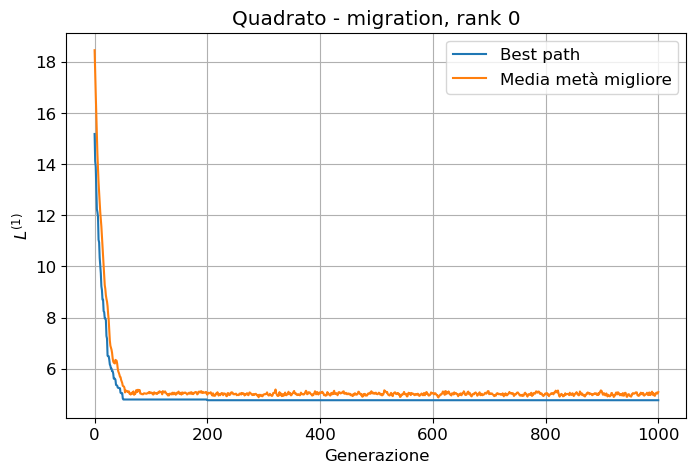

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

# Miglior cammino trovato dal rank 0 a ogni generazione.
ax.plot(history_square_migration[:, 0],
        history_square_migration[:, 1],
        label="Best path")

# Media di L^(1) sulla metà migliore della popolazione del rank 0.
ax.plot(history_square_migration[:, 0],
        history_square_migration[:, 2],
        label="Media metà migliore")

ax.set_title("Quadrato - migration, rank 0")
ax.set_xlabel("Generazione")
ax.set_ylabel("$L^{(1)}$")
ax.grid(True)
ax.legend()

plt.show()

## 1.3 Miglior percorso nel quadrato

I percorsi seguenti sono letti dai file `bestpath_coordinates`, usando il rank migliore ricavato dal file `final_summary`.

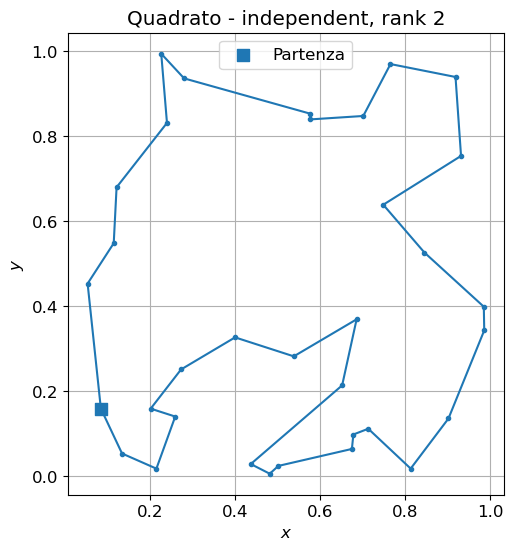

In [5]:
# Leggo il percorso del rank migliore della run indipendente.
coords_square_independent = np.loadtxt(
    OUTPUT_DIR / "square" / f"bestpath_coordinates_square_independent_rank_{best_rank_square_independent}.dat",
    comments="#"
)[:, :2]

fig, ax = plt.subplots(figsize=(6, 6))

# Disegno il cammino chiuso salvato dal C++.
ax.plot(coords_square_independent[:, 0],
        coords_square_independent[:, 1],
        marker="o",
        markersize=3)

# Evidenzio la città iniziale del percorso.
ax.scatter(coords_square_independent[0, 0],
           coords_square_independent[0, 1],
           marker="s",
           s=80,
           label="Partenza")

ax.set_title(f"Quadrato - independent, rank {best_rank_square_independent}")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_aspect("equal")
ax.grid(True)
ax.legend()

plt.show()

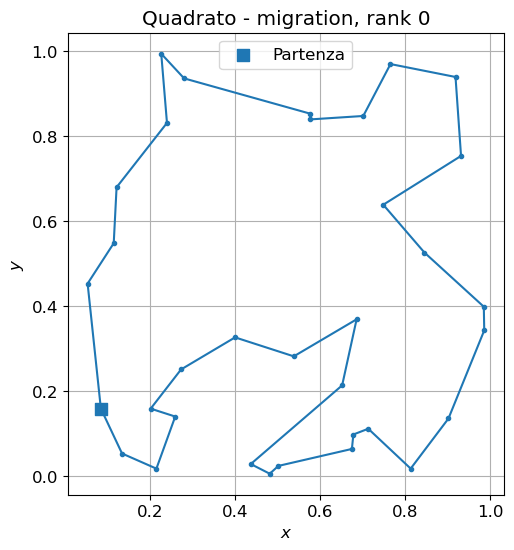

In [6]:
coords_square_migration = np.loadtxt(
    OUTPUT_DIR / "square" / f"bestpath_coordinates_square_migration_rank_{best_rank_square_migration}.dat",
    comments="#"
)[:, :2]

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(coords_square_migration[:, 0],
        coords_square_migration[:, 1],
        marker="o",
        markersize=3)

ax.scatter(coords_square_migration[0, 0],
           coords_square_migration[0, 1],
           marker="s",
           s=80,
           label="Partenza")

ax.set_title(f"Quadrato - migration, rank {best_rank_square_migration}")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_aspect("equal")
ax.grid(True)
ax.legend()

plt.show()

Nel caso del quadrato la migrazione non produce un miglioramento evidente della lunghezza finale. Questo non è un problema: con 34 città e 1000 generazioni anche le run indipendenti riescono già a raggiungere molto spesso lo stesso minimo. La migrazione diventa più interessante nel caso più grande, dove la ricerca può rimanere più facilmente intrappolata in minimi locali diversi.

# 2. Capoluoghi di provincia italiani

Nel secondo caso applico lo stesso codice ai 110 capoluoghi di provincia italiani. Le coordinate sono longitudine e latitudine, quindi il valore di $L^{(1)}$ è espresso nelle unità del dataset e non va interpretato direttamente come una distanza in chilometri.

Anche qui confronto run indipendente e run con migrazione. La history resta riferita al `rank 0`, mentre il file summary permette di scegliere il miglior rank finale tra tutti i continenti.

In [7]:
summary_italy_independent = np.loadtxt(
    OUTPUT_DIR / "italy" / "final_summary_italy_independent.dat",
    comments="#"
)

summary_italy_migration = np.loadtxt(
    OUTPUT_DIR / "italy" / "final_summary_italy_migration.dat",
    comments="#"
)

history_italy_independent = np.loadtxt(
    OUTPUT_DIR / "italy" / "history_italy_independent_rank_0.dat",
    comments="#"
)

history_italy_migration = np.loadtxt(
    OUTPUT_DIR / "italy" / "history_italy_migration_rank_0.dat",
    comments="#"
)

best_italy_independent = summary_italy_independent[np.argmin(summary_italy_independent[:, 1])]
best_italy_migration = summary_italy_migration[np.argmin(summary_italy_migration[:, 1])]

best_rank_italy_independent = int(best_italy_independent[0])
best_rank_italy_migration = int(best_italy_migration[0])

print("Run           L_best        Best half")
print("Independent  %.4f      %.4f" % (best_italy_independent[1], best_italy_independent[2]))
print("Migration    %.4f      %.4f" % (best_italy_migration[1], best_italy_migration[2]))

Run           L_best        Best half
Independent  68.0171      71.1618
Migration    64.5938      67.8504


## 2.1 Andamento del costo — run indipendente

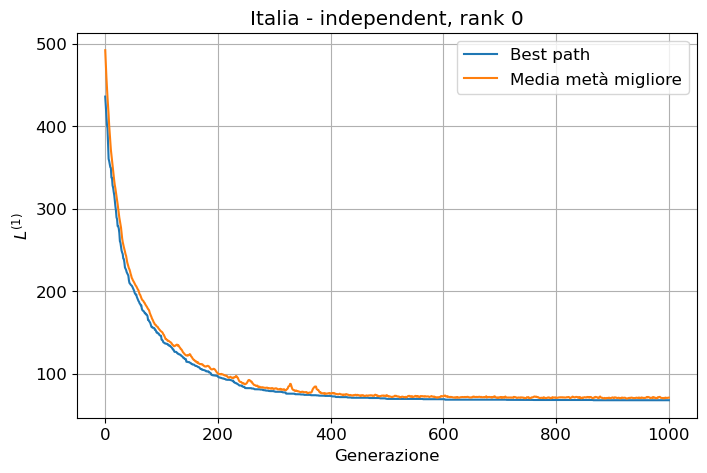

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

# Miglior cammino trovato dal rank 0 a ogni generazione.
ax.plot(history_italy_independent[:, 0],
        history_italy_independent[:, 1],
        label="Best path")

# Media di L^(1) sulla metà migliore della popolazione del rank 0.
ax.plot(history_italy_independent[:, 0],
        history_italy_independent[:, 2],
        label="Media metà migliore")

ax.set_title("Italia - independent, rank 0")
ax.set_xlabel("Generazione")
ax.set_ylabel("$L^{(1)}$")
ax.grid(True)
ax.legend()

plt.show()

## 2.2 Andamento del costo — run con migrazione

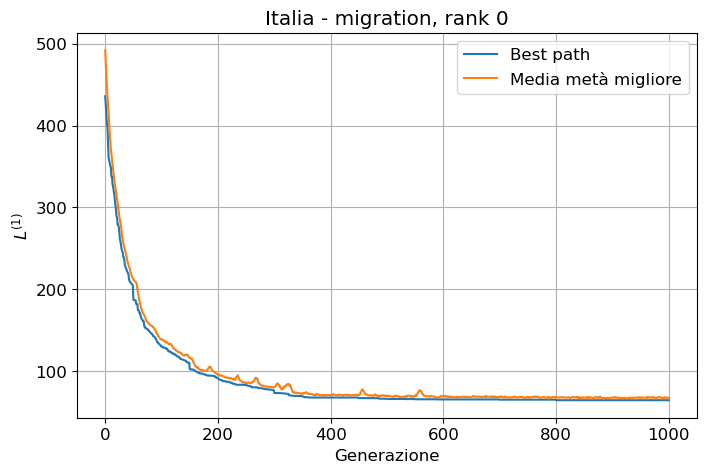

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_italy_migration[:, 0],
        history_italy_migration[:, 1],
        label="Best path")

ax.plot(history_italy_migration[:, 0],
        history_italy_migration[:, 2],
        label="Media metà migliore")

ax.set_title("Italia - migration, rank 0")
ax.set_xlabel("Generazione")
ax.set_ylabel("$L^{(1)}$")
ax.grid(True)
ax.legend()

plt.show()

## 2.3 Zoom sulle ultime 500 generazioni

Lo zoom finale serve a controllare se il costo si è stabilizzato. In questa fase il best path può rimanere costante per molte generazioni, mentre la media della metà migliore continua a misurare la convergenza della popolazione.

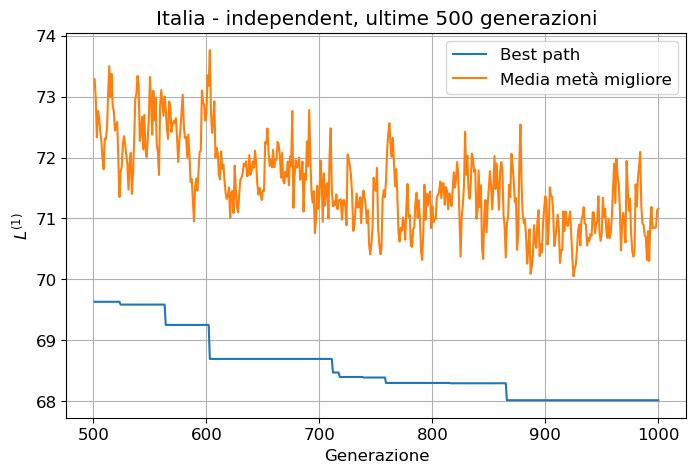

In [10]:
# Numero di generazioni finali da visualizzare nello zoom.
last_generations = 500

# Seleziono le ultime last_generations righe della history.
italy_independent_zoom = history_italy_independent[-last_generations:]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(italy_independent_zoom[:, 0],
        italy_independent_zoom[:, 1],
        label="Best path")

ax.plot(italy_independent_zoom[:, 0],
        italy_independent_zoom[:, 2],
        label="Media metà migliore")

ax.set_title("Italia - independent, ultime 500 generazioni")
ax.set_xlabel("Generazione")
ax.set_ylabel("$L^{(1)}$")
ax.grid(True)
ax.legend()

plt.show()

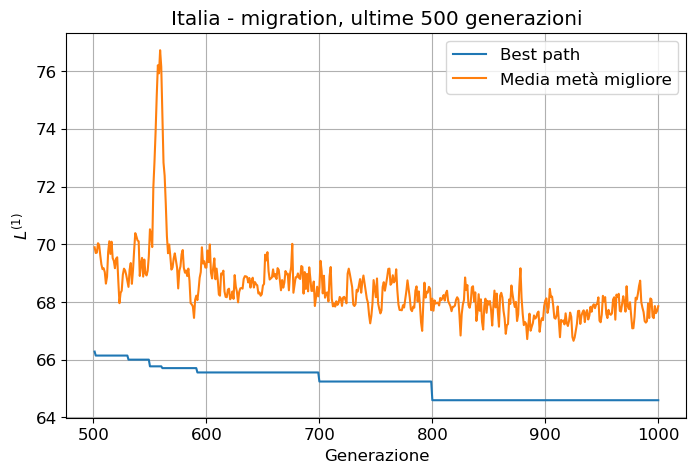

In [11]:
last_generations = 500

italy_migration_zoom = history_italy_migration[-last_generations:]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(italy_migration_zoom[:, 0],
        italy_migration_zoom[:, 1],
        label="Best path")

ax.plot(italy_migration_zoom[:, 0],
        italy_migration_zoom[:, 2],
        label="Media metà migliore")

ax.set_title("Italia - migration, ultime 500 generazioni")
ax.set_xlabel("Generazione")
ax.set_ylabel("$L^{(1)}$")
ax.grid(True)
ax.legend()

plt.show()


## 2.4 Miglior percorso sui capoluoghi italiani

Nei grafici seguenti il percorso viene rappresentato sulla mappa dell'Italia usando Cartopy. Le coordinate sono quelle del file `cap_prov_ita.dat`.

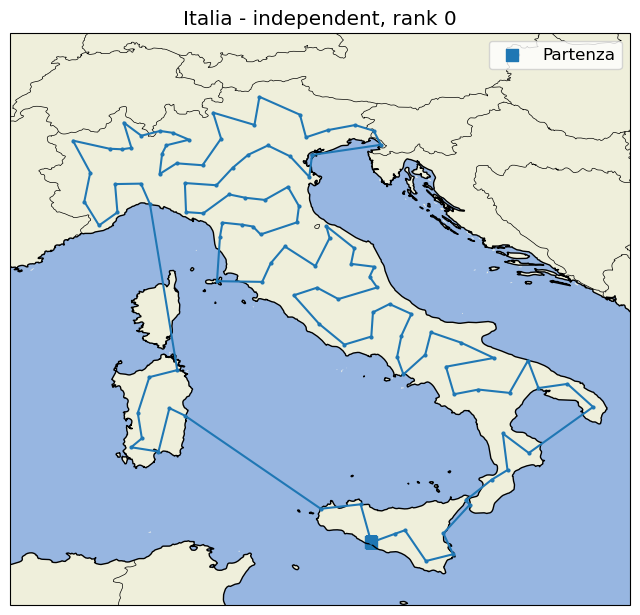

In [12]:
coords_italy_independent = np.loadtxt(
    OUTPUT_DIR / "italy" / f"bestpath_coordinates_italy_independent_rank_{best_rank_italy_independent}.dat",
    comments="#"
)[:, :2]

fig = plt.figure(figsize=(8, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

# Imposto la finestra geografica e aggiungo gli elementi della mappa.
ax.set_extent([6, 19, 36, 48], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Disegno il cammino chiuso usando longitudine e latitudine.
ax.plot(coords_italy_independent[:, 0],
        coords_italy_independent[:, 1],
        marker="o",
        markersize=2,
        transform=ccrs.PlateCarree())

# Evidenzio la città iniziale del percorso.
ax.scatter(coords_italy_independent[0, 0],
           coords_italy_independent[0, 1],
           marker="s",
           s=80,
           transform=ccrs.PlateCarree(),
           label="Partenza")

ax.set_title(f"Italia - independent, rank {best_rank_italy_independent}")
ax.legend()
plt.show()

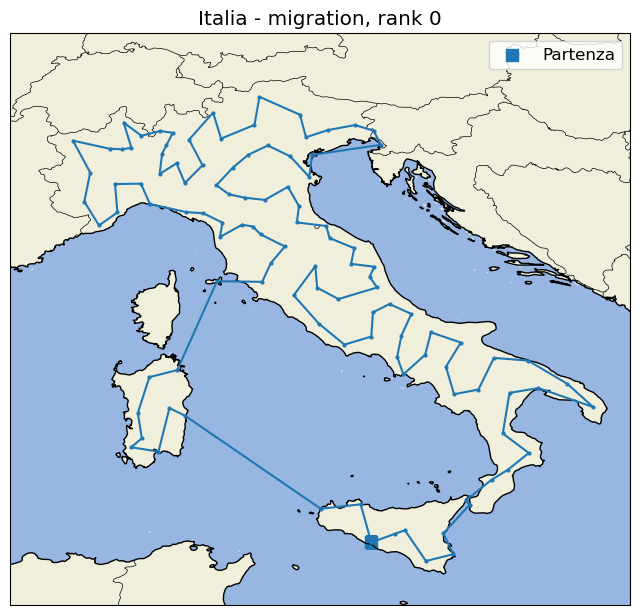

In [13]:
coords_italy_migration = np.loadtxt(
    OUTPUT_DIR / "italy" / f"bestpath_coordinates_italy_migration_rank_{best_rank_italy_migration}.dat",
    comments="#"
)[:, :2]

fig = plt.figure(figsize=(8, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([6, 19, 36, 48], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

ax.plot(coords_italy_migration[:, 0],
        coords_italy_migration[:, 1],
        marker="o",
        markersize=2,
        transform=ccrs.PlateCarree())

ax.scatter(coords_italy_migration[0, 0],
           coords_italy_migration[0, 1],
           marker="s",
           s=80,
           transform=ccrs.PlateCarree(),
           label="Partenza")

ax.set_title(f"Italia - migration, rank {best_rank_italy_migration}")
ax.legend()
plt.show()

Nel caso dei capoluoghi italiani la migrazione migliora in modo netto il risultato finale. La differenza rispetto al quadrato è naturale: il problema ha più città e uno spazio di ricerca molto più grande, quindi lo scambio periodico di buoni individui tra continenti aiuta a diffondere soluzioni efficaci e a ridurre il rischio che una singola popolazione resti bloccata in un minimo locale.

Un aspetto da notare è che, nel file summary della run con migrazione, tutti i rank finali hanno la stessa best length. Questo indica che il miglior cammino si è propagato tra i continenti durante la simulazione. Non è un difetto del codice: è proprio l'effetto atteso della migrazione, purché la popolazione mantenga comunque abbastanza diversità, come mostrato dal valore della media sulla metà migliore.

## Riassunto finale

La tabella seguente raccoglie i risultati finali ottenuti nei diversi run. Per ogni caso riporto il miglior valore finale di $L^{(1)}$ trovato tra tutti i rank MPI e la media della metà migliore della popolazione nello stesso rank.

In [14]:
italy_final_results = pd.DataFrame([
    {
        "Run": "Independent",
        "L_best": best_italy_independent[1],
        "Best half": best_italy_independent[2],
    },
    {
        "Run": "Migration",
        "L_best": best_italy_migration[1],
        "Best half": best_italy_migration[2],
    },
])

italy_final_results.style.format({
    "L_best": "{:.4f}",
    "Best half": "{:.4f}",
}).hide(axis="index")

Run,L_best,Best half
Independent,68.0171,71.1618
Migration,64.5938,67.8504


# Conclusioni

La parallelizzazione con MPI è stata realizzata a livello di popolazioni, non a livello delle singole operazioni genetiche. Questa scelta è adatta al TSP perché ogni continente può lavorare quasi indipendentemente e la comunicazione avviene solo ogni $N_\mathrm{migr}$ generazioni.

La versione indipendente sfrutta MPI solo per lanciare più ricerche genetiche separate. La versione con migrazione aggiunge invece una comunicazione periodica dei migliori individui, implementata con `MPI_Bcast`, `MPI_Isend`, `MPI_Recv` e `MPI_Wait`.

Sul quadrato le due strategie raggiungono risultati molto simili, perché il problema è più piccolo. Sul dataset dei capoluoghi italiani la migrazione porta invece a un cammino finale più corto rispetto alle run indipendenti. Questo mostra che il modello a continenti è utile quando il paesaggio di ottimizzazione è più complesso e le singole popolazioni possono beneficiare dello scambio di informazione genetica.